# **STEP0: Mount and extraction**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Copy using the exact path from your second screenshot
!cp "/content/drive/MyDrive/CV_Project/Dataset/idd_dense_dataset.zip" /content/dataset.zip

# 2. Unzip it
!unzip -q /content/dataset.zip -d /content/faster_rcnn_data

# 3. Verify the internal structure based on what you told me
# The folders should be inside faster_rcnn_data/dataset/
data_path = "/content/faster_rcnn_data/dataset"

import os
if os.path.exists(data_path):
    print("✅ Success! Found the dataset folder.")
    print("Folders found:", os.listdir(data_path))
    print("Training images:", len(os.listdir(os.path.join(data_path, "images/train"))))
    print("Training labels:", len(os.listdir(os.path.join(data_path, "labels/train"))))
else:
    print("❌ Path error. Please check if the zip contains a 'dataset' folder.")

✅ Success! Found the dataset folder.
Folders found: ['images', 'labels', 'annotations']
Training images: 4000
Training labels: 4000


# **STEP1 Data adaptor**

In [3]:
import os
import torch
from PIL import Image
import numpy as np

class YOLOToFasterRCNNDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.root = root
        self.img_dir = os.path.join(root, "images/train")
        self.label_dir = os.path.join(root, "labels/train")

        self.images = sorted(os.listdir(self.img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace(".jpg", ".txt"))

        # Load image
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        boxes = []
        labels = []

        # Read label file
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f.readlines():
                    cls, xc, yc, bw, bh = map(float, line.strip().split())

                    # Convert to pixels
                    xc *= w
                    yc *= h
                    bw *= w
                    bh *= h

                    # Convert to corners
                    x_min = xc - bw / 2
                    y_min = yc - bh / 2
                    x_max = xc + bw / 2
                    y_max = yc + bh / 2

# Only keep valid boxes
                    if (x_max - x_min > 1) and (y_max - y_min > 1):
                          boxes.append([x_min, y_min, x_max, y_max])
                          labels.append(int(cls) + 1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        # Convert image to tensor
        img = torch.tensor(np.array(img) / 255.0, dtype=torch.float32).permute(2, 0, 1)

        return img, target

In [4]:
dataset = YOLOToFasterRCNNDataset("/content/faster_rcnn_data/dataset")

img, target = dataset[0]

print("Image shape:", img.shape)
print("Boxes:", target["boxes"])
print("Labels:", target["labels"])

Image shape: torch.Size([3, 1080, 1921])
Boxes: tensor([[9.3600e+02, 5.0800e+02, 1.0180e+03, 5.7000e+02],
        [1.0940e+03, 5.4000e+02, 1.1390e+03, 5.8000e+02],
        [1.1930e+03, 5.3300e+02, 1.2390e+03, 5.8200e+02],
        [1.2480e+03, 5.3800e+02, 1.2900e+03, 5.7000e+02],
        [1.2700e+03, 5.4400e+02, 1.3310e+03, 5.7300e+02],
        [1.3070e+03, 5.3800e+02, 1.3160e+03, 5.4600e+02],
        [1.3350e+03, 5.3300e+02, 1.3640e+03, 5.5800e+02],
        [1.3440e+03, 5.3000e+02, 1.4260e+03, 5.8900e+02],
        [1.4150e+03, 5.2600e+02, 1.4670e+03, 5.7200e+02],
        [1.4420e+03, 4.9700e+02, 1.6020e+03, 5.8700e+02],
        [1.4450e+03, 5.3300e+02, 1.6780e+03, 6.7000e+02],
        [1.7000e+03, 5.1900e+02, 1.7620e+03, 5.5600e+02],
        [1.7620e+03, 5.2100e+02, 1.7880e+03, 5.5700e+02],
        [1.7840e+03, 4.8400e+02, 1.9140e+03, 5.3800e+02],
        [1.7720e+03, 5.0200e+02, 1.9200e+03, 6.1200e+02],
        [1.7490e+03, 6.0100e+02, 1.9200e+03, 8.0100e+02],
        [1.7660e+03, 5.3

# ** Step 2 Loading Faster RCNN**

In [5]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
model = fasterrcnn_resnet50_fpn(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 166MB/s]


In [6]:
all_labels = set()

for i in range(100):
    _, target = dataset[i]
    all_labels.update(target["labels"].tolist())

print("Classes found:", all_labels)
print("Num classes:", max(all_labels) + 1)

Classes found: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
Num classes: 13


In [7]:
num_classes = 13

In [8]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

In [9]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
print("Model loaded successfully")
print(device)

Model loaded successfully
cuda


# **STEP 3 Training**

In [10]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

dataset = YOLOToFasterRCNNDataset("/content/faster_rcnn_data/dataset")

data_loader = DataLoader(
    dataset,
    batch_size=2,   # keep small (GPU safe)
    shuffle=True,
    collate_fn=collate_fn
)

print("Total batches:", len(data_loader))

Total batches: 2000


In [11]:
import os
import time
import torch

# =========================
# 📁 PATH SETUP
# =========================
checkpoint_dir = "/content/drive/MyDrive/CV_Project/Dataset/Faster RCNN"
os.makedirs(checkpoint_dir, exist_ok=True)

# =========================
# ⚙️ TRAINING SETTINGS
# =========================
total_epochs = 5

# =========================
# 🔧 CREATE OPTIMIZER FIRST (IMPORTANT FIX)
# =========================
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# =========================
# 🔍 FIND LATEST CHECKPOINT
# =========================
files = os.listdir(checkpoint_dir)
epoch_numbers = []

for f in files:
    if f.startswith("model_epoch_"):
        epoch_num = int(f.split("_")[-1].split(".")[0])
        epoch_numbers.append(epoch_num)

if len(epoch_numbers) > 0:
    latest_epoch = max(epoch_numbers)
    latest_checkpoint = os.path.join(checkpoint_dir, f"model_epoch_{latest_epoch}.pth")
    print(f"🔁 Resuming from Epoch {latest_epoch}")
else:
    latest_epoch = 0
    latest_checkpoint = None
    print("🆕 Starting fresh training")

# =========================
# 📥 LOAD CHECKPOINT
# =========================
if latest_checkpoint is not None:
    checkpoint = torch.load(latest_checkpoint)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch']
else:
    start_epoch = 0

print(f"➡️ Starting from epoch: {start_epoch}\n")

# =========================
# 🚀 TRAINING LOOP
# =========================
print("🚀 Training Started...\n")

total_start_time = time.time()
total_batches = len(data_loader)

for epoch in range(start_epoch, total_epochs):
    epoch_start = time.time()
    model.train()

    epoch_loss = 0.0

    for i, (images, targets) in enumerate(data_loader):
        iter_start = time.time()

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        loss_value = losses.item()
        epoch_loss += loss_value

        # ===== ETA CALCULATION =====
        batches_done = epoch * total_batches + i + 1
        total_batches_all = total_epochs * total_batches

        elapsed_time = time.time() - total_start_time
        avg_time_per_batch = elapsed_time / batches_done
        remaining_batches = total_batches_all - batches_done
        eta_seconds = avg_time_per_batch * remaining_batches

        if i % 20 == 0:
            print(f"[Epoch {epoch+1}/{total_epochs}] "
                  f"[Batch {i}/{total_batches}] "
                  f"[Loss: {loss_value:.4f}] "
                  f"[ETA: {eta_seconds/60:.2f} mins]")

    # =========================
    # 💾 SAVE CHECKPOINT
    # =========================
    checkpoint_path = os.path.join(checkpoint_dir, f"model_epoch_{epoch+1}.pth")

    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, checkpoint_path)

    epoch_time = time.time() - epoch_start

    print(f"\n💾 Saved: {checkpoint_path}")
    print(f"✅ Epoch {epoch+1} Done | Avg Loss: {epoch_loss / total_batches:.4f}")
    print(f"⏱️ Time: {epoch_time/60:.2f} mins\n")

# =========================
# 🎉 DONE
# =========================
total_time = time.time() - total_start_time
print(f"🎉 Training Complete! Total Time: {total_time/60:.2f} mins")

🔁 Resuming from Epoch 3
➡️ Starting from epoch: 3

🚀 Training Started...

[Epoch 4/5] [Batch 0/2000] [Loss: 0.8653] [ETA: 0.03 mins]
[Epoch 4/5] [Batch 20/2000] [Loss: 0.6186] [ETA: 0.17 mins]
[Epoch 4/5] [Batch 40/2000] [Loss: 0.9678] [ETA: 0.31 mins]
[Epoch 4/5] [Batch 60/2000] [Loss: 1.1798] [ETA: 0.44 mins]
[Epoch 4/5] [Batch 80/2000] [Loss: 1.0472] [ETA: 0.58 mins]
[Epoch 4/5] [Batch 100/2000] [Loss: 1.0616] [ETA: 0.72 mins]
[Epoch 4/5] [Batch 120/2000] [Loss: 0.9036] [ETA: 0.86 mins]
[Epoch 4/5] [Batch 140/2000] [Loss: 1.0820] [ETA: 1.00 mins]
[Epoch 4/5] [Batch 160/2000] [Loss: 1.0273] [ETA: 1.14 mins]
[Epoch 4/5] [Batch 180/2000] [Loss: 0.9920] [ETA: 1.29 mins]
[Epoch 4/5] [Batch 200/2000] [Loss: 1.1073] [ETA: 1.44 mins]
[Epoch 4/5] [Batch 220/2000] [Loss: 1.0810] [ETA: 1.59 mins]
[Epoch 4/5] [Batch 240/2000] [Loss: 0.8189] [ETA: 1.74 mins]
[Epoch 4/5] [Batch 260/2000] [Loss: 0.8918] [ETA: 1.87 mins]
[Epoch 4/5] [Batch 280/2000] [Loss: 0.6358] [ETA: 2.01 mins]
[Epoch 4/5] [Batc

# we might extend this to 5 epochs, for now, we have trained only 3.

# **STEP4: Evaluation**

In [14]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# recreate model
num_classes = 13
model = fasterrcnn_resnet50_fpn(pretrained=False)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# load weights
model_path = "/content/drive/MyDrive/CV_Project/Dataset/Faster RCNN/model_epoch_5.pth"
checkpoint = torch.load(model_path)

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()
model.to(device)

print("✅ Model loaded")

✅ Model loaded


In [15]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - inter

    return inter / union if union > 0 else 0

In [16]:
bins = [(0,0.2),(0.2,0.4),(0.4,0.6),(0.6,0.8),(0.8,1.0)]

fn_counts = {b:0 for b in bins}
total_counts = {b:0 for b in bins}

In [17]:
import time

AREA_THRESHOLD = 1000
total_images = len(dataset)

start_time = time.time()

for idx in range(total_images):
    img, target = dataset[idx]

    img = img.to(device)

    with torch.no_grad():
        pred = model([img])[0]

    gt_boxes = target["boxes"].cpu().numpy()
    pred_boxes = pred["boxes"].cpu().numpy()

    # filter small GT objects
    valid_gt = []
    for box in gt_boxes:
        area = (box[2]-box[0])*(box[3]-box[1])
        if area > AREA_THRESHOLD:
            valid_gt.append(box)

    for i, gt in enumerate(valid_gt):

        max_iou = 0
        for j, other in enumerate(valid_gt):
            if i != j:
                max_iou = max(max_iou, compute_iou(gt, other))

        for b in bins:
            if b[0] <= max_iou < b[1]:
                total_counts[b] += 1

                detected = False
                for pb in pred_boxes:
                    if compute_iou(gt, pb) > 0.5:
                        detected = True
                        break

                if not detected:
                    fn_counts[b] += 1

                break

    # 🔥 ETA CALCULATION
    if idx % 50 == 0:  # print every 50 images
        elapsed = time.time() - start_time
        avg_time_per_img = elapsed / (idx + 1)
        remaining = (total_images - idx - 1) * avg_time_per_img

        print(f"[{idx}/{total_images}] "
              f"Elapsed: {elapsed/60:.2f} min | "
              f"ETA: {remaining/60:.2f} min")

[0/4000] Elapsed: 0.00 min | ETA: 17.22 min
[50/4000] Elapsed: 0.16 min | ETA: 12.47 min
[100/4000] Elapsed: 0.32 min | ETA: 12.40 min
[150/4000] Elapsed: 0.48 min | ETA: 12.25 min
[200/4000] Elapsed: 0.64 min | ETA: 12.19 min
[250/4000] Elapsed: 0.81 min | ETA: 12.11 min
[300/4000] Elapsed: 0.97 min | ETA: 11.90 min
[350/4000] Elapsed: 1.12 min | ETA: 11.69 min
[400/4000] Elapsed: 1.28 min | ETA: 11.51 min
[450/4000] Elapsed: 1.44 min | ETA: 11.33 min
[500/4000] Elapsed: 1.60 min | ETA: 11.14 min
[550/4000] Elapsed: 1.76 min | ETA: 10.99 min
[600/4000] Elapsed: 1.92 min | ETA: 10.84 min
[650/4000] Elapsed: 2.07 min | ETA: 10.67 min
[700/4000] Elapsed: 2.23 min | ETA: 10.52 min
[750/4000] Elapsed: 2.40 min | ETA: 10.36 min
[800/4000] Elapsed: 2.55 min | ETA: 10.19 min
[850/4000] Elapsed: 2.71 min | ETA: 10.02 min
[900/4000] Elapsed: 2.87 min | ETA: 9.86 min
[950/4000] Elapsed: 3.02 min | ETA: 9.69 min
[1000/4000] Elapsed: 3.18 min | ETA: 9.53 min
[1050/4000] Elapsed: 3.34 min | ETA: 9.

In [18]:
print("\n📊 False Negative Rates:\n")

for b in bins:
    if total_counts[b] > 0:
        fn_rate = fn_counts[b] / total_counts[b]
        print(f"IoU {b}: FN Rate = {fn_rate:.4f}")
    else:
        print(f"IoU {b}: No samples")


📊 False Negative Rates:

IoU (0, 0.2): FN Rate = 0.1353
IoU (0.2, 0.4): FN Rate = 0.1242
IoU (0.4, 0.6): FN Rate = 0.0566
IoU (0.6, 0.8): FN Rate = 0.0473
IoU (0.8, 1.0): FN Rate = 0.0787


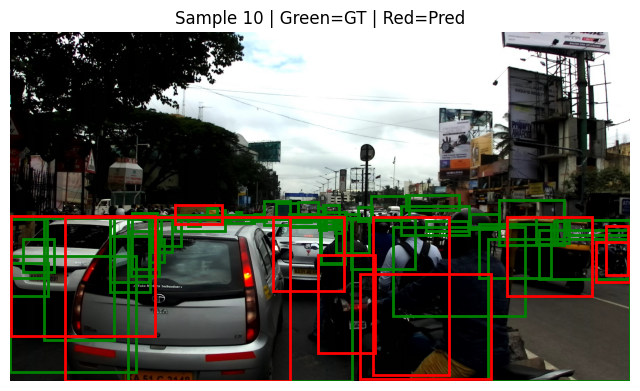

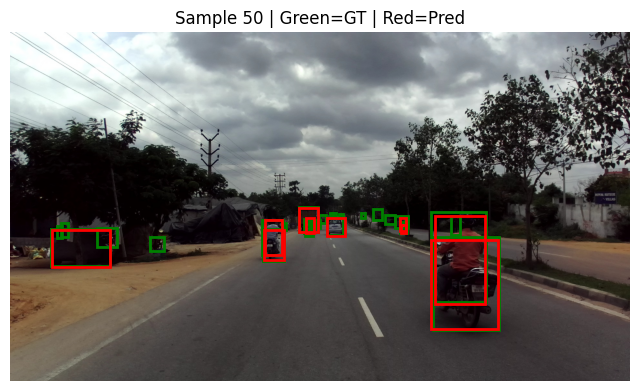

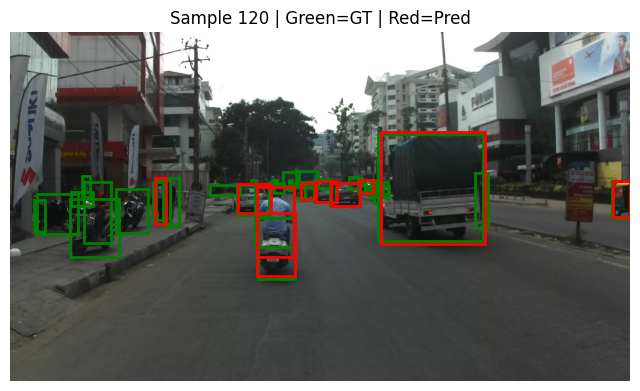

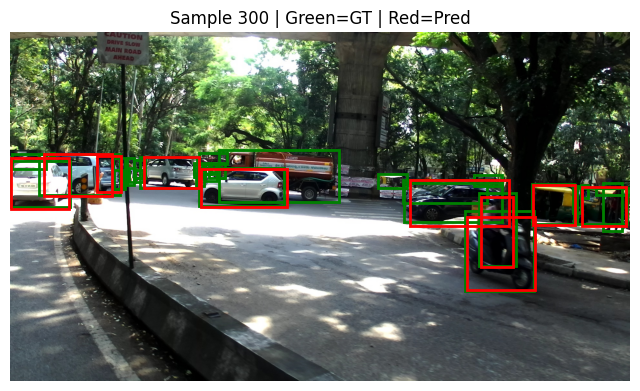

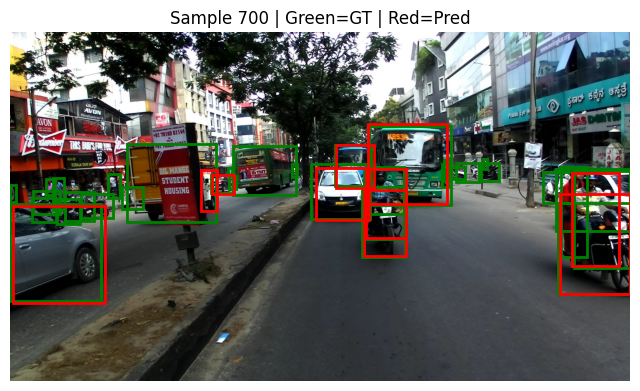

In [19]:
import matplotlib.pyplot as plt
import random

num_samples = 5  # how many images to show

# manually pick dense scenes
indices = [10, 50, 120, 300, 700]

for idx in indices:
    img, target = dataset[idx]

    with torch.no_grad():
        pred = model([img.to(device)])[0]

    plt.figure(figsize=(8,6))
    plt.imshow(img.permute(1,2,0).cpu())

    # GT boxes (green)
    for box in target['boxes']:
        x1,y1,x2,y2 = box
        plt.gca().add_patch(
            plt.Rectangle((x1,y1), x2-x1, y2-y1,
                          fill=False, color='green', linewidth=2)
        )

    # Pred boxes (red)
    for box in pred['boxes'][:10]:  # limit clutter
        x1,y1,x2,y2 = box.cpu()
        plt.gca().add_patch(
            plt.Rectangle((x1,y1), x2-x1, y2-y1,
                          fill=False, color='red', linewidth=2)
        )

    plt.title(f"Sample {idx} | Green=GT | Red=Pred")
    plt.axis('off')
    plt.show()

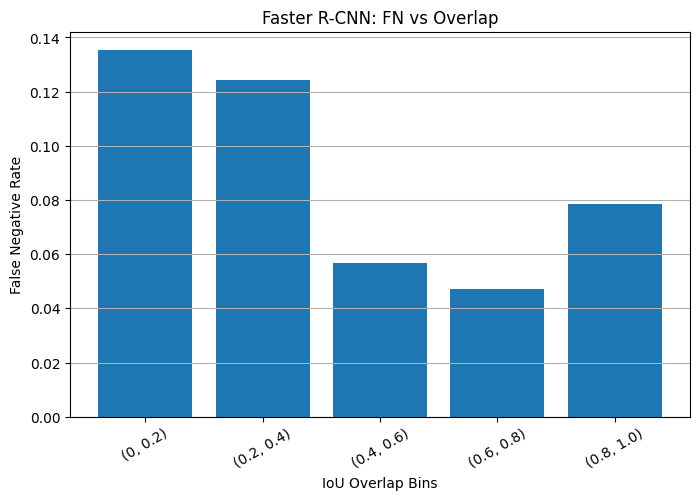

In [20]:
import matplotlib.pyplot as plt

# prepare data
labels = [str(b) for b in bins]
fn_values = [
    fn_counts[b] / total_counts[b] if total_counts[b] > 0 else 0
    for b in bins
]

plt.figure(figsize=(8,5))
plt.bar(labels, fn_values)

plt.xlabel("IoU Overlap Bins")
plt.ylabel("False Negative Rate")
plt.title("Faster R-CNN: FN vs Overlap")
plt.xticks(rotation=30)
plt.grid(axis='y')

plt.show()

# **Latency**

In [21]:
import time

model.eval()

num_runs = 50

img, _ = dataset[0]
img = img.to(device)

# warm-up (important)
for _ in range(5):
    with torch.no_grad():
        _ = model([img])

start = time.time()

for _ in range(num_runs):
    with torch.no_grad():
        _ = model([img])

end = time.time()

avg_time = (end - start) / num_runs

print(f"Average inference time: {avg_time*1000:.2f} ms per image")

Average inference time: 142.46 ms per image
